In [1]:
import torch
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from model import Generator
from evaluate import load_generator, generate_samples, pairwise_pixel_distance, compare_before_after

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nz = 100

In [3]:
CHECKPOINT_PATH = "./runs/baseline_e5/netG_epoch_004.pth"


### load the generator

In [ ]:
netG = Generator(nz=nz, ngf=64, nc=3).to(device)
netG.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
netG.eval()
print(f"Loaded generator")

Loaded generator


### see a grid of random generated images

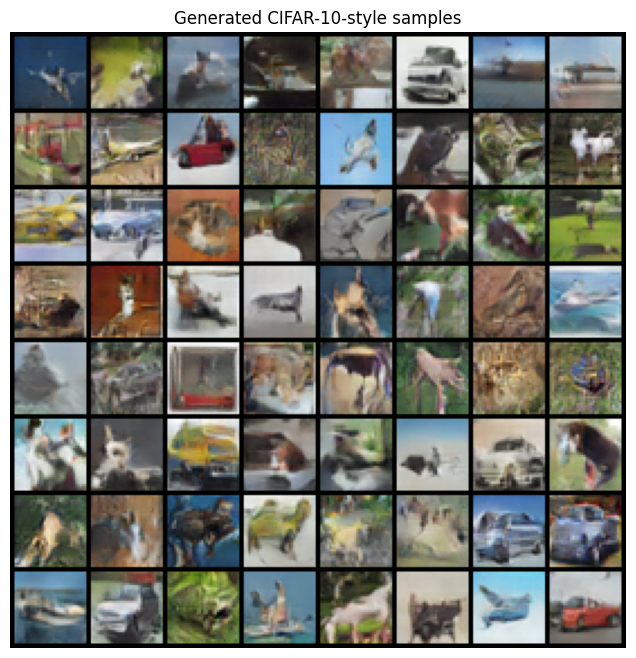

In [7]:
with torch.no_grad():
    noise = torch.randn(64, nz, 1, 1, device=device)
    fake_imgs = netG(noise).cpu()

grid = vutils.make_grid(fake_imgs, nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated CIFAR-10-style samples")
plt.imshow(grid.permute(1, 2, 0))
plt.show()

In [ ]:
PRETRAINED_PATH = "../pretrained/netG_epoch_199.pth"
BASELINE_PATH   = "./runs/baseline_e10/netG_epoch_009.pth"
SN_PATH         = "./runs/sn_e10/netG_epoch_009.pth"
LOWLR_PATH      = "./runs/lowlr_e10/netG_epoch_009.pth"

Avg pairwise pixel distance — pretrained baseline: 29.3367
Avg pairwise pixel distance — fine-tuned model:    28.0493


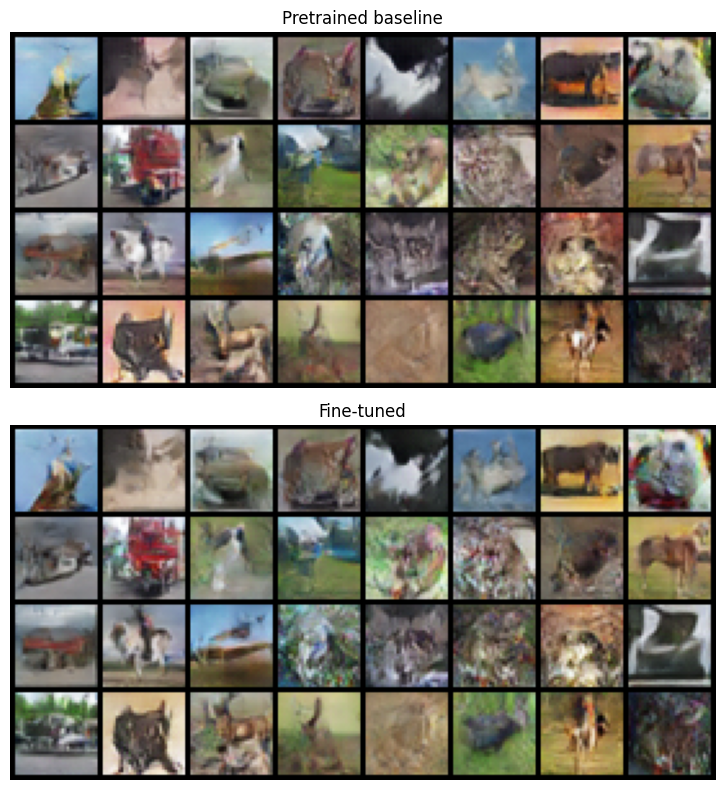

In [10]:
dist_pre, dist_fine = compare_before_after(
    pretrained_path=PRETRAINED_PATH,
    finetuned_path=BASELINE_PATH,
    device=device,
)

Avg pairwise pixel distance — pretrained baseline: 31.7433
Avg pairwise pixel distance — fine-tuned model:    29.6229


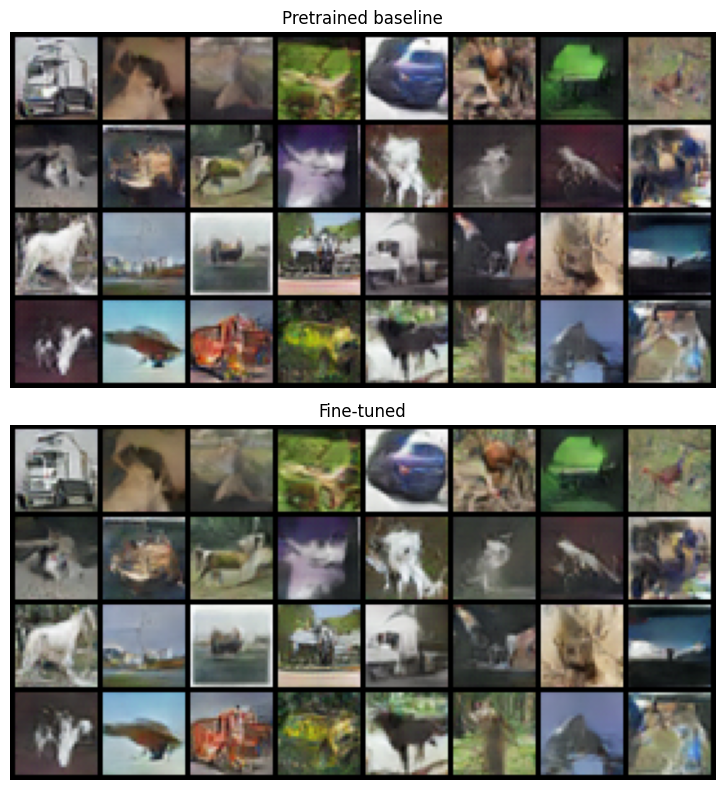

In [11]:
dist_pre, dist_fine = compare_before_after(
    pretrained_path=PRETRAINED_PATH,
    finetuned_path= LOWLR_PATH,
    device=device,
)